In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
DATA_ROOT = '../data'

In [8]:
#logTPM_res = pd.read_csv(f'{DATA_ROOT}/MSE_results_logTPM.csv', index_col = 0)
TPM_res = pd.read_csv(f'{DATA_ROOT}/Pearsons_results.csv', index_col = 0, header = 0)
reference_res = pd.read_csv(f'{DATA_ROOT}/reference_MSE_results.csv', index_col=0, header = 0)
#external_res = pd.read_csv(f'{DATA_ROOT}/external_MSE_TPM.csv', index_col= 0, header = 0)
merged_results = pd.read_csv(f'{DATA_ROOT}/TPM_res_in_features.csv', index_col= 0, header = 0)

In [32]:
np.sum(reference_res['stopped_early'])

14654.0

In [36]:
TPM_res.shape

(16100, 3)

In [33]:
np.sum(TPM_res['stopped_early'])

16097.0

In [37]:
TPM_res

,train_score,test_score,stopped_early
A2M,0.969889,0.961446,1.0
A2ML1,1.145598,1.169069,1.0
A3GALT2,0.847709,0.856579,1.0
A4GALT,0.534433,0.527976,1.0
AAAS,0.322987,0.324133,1.0
...,...,...,...
ZYG11A,1.416881,1.392014,1.0
ZYG11B,0.399702,0.410859,1.0
ZYX,0.279193,0.281179,1.0
ZZEF1,0.329884,0.330753,1.0


In [12]:
TPM_res.loc[TPM_res['test_score'] < 0.2, :].shape[0]

10491

In [13]:
#log_to_plot = pd.melt(logTPM_res)
TPM_to_plot = pd.melt(TPM_res)

In [14]:
#create function make train test MSE violin plot
def loss_violin_plot(df, palette, title, figtitle):
    fig, ax = plt.subplots()
    ax = sns.violinplot(data = df, x = 'variable', y="value", hue = 'variable', palette=palette)
    ax.set_ylabel('MSE', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
    fig.canvas.draw()
    labels = [item.get_text() for item in ax.get_xticklabels()]
    labels[0], labels[1] = ['Training', 'Test']
    ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
    fig.suptitle(title, fontsize = 20)
    plt.savefig(figtitle, dpi = 300)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_8909/1421562481.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


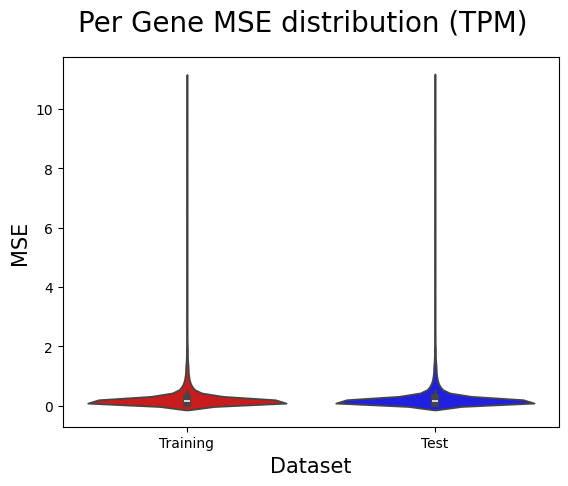

In [15]:
loss_violin_plot(TPM_to_plot, palette=['#e60000', '#0000ff'], title ='Per Gene MSE distribution (TPM)', figtitle= 'figures/TPM_train_test')

# External dataset erorr scores

ValueError: Could not interpret value `log_external` for `y`. An entry with this name does not appear in `data`.

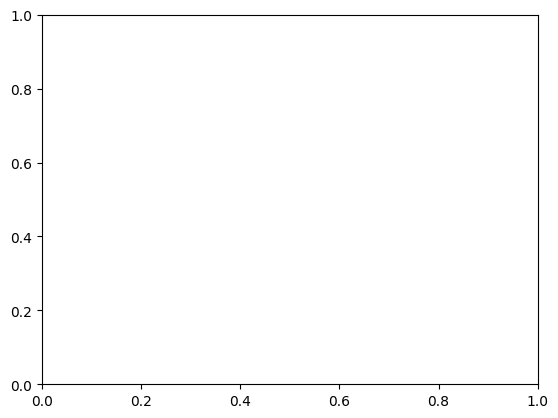

In [38]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'log_external', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Log(External MSE + 1)', fontsize = 10)
fig.suptitle('Training vs External MSE and Model Size')
plt.savefig('figures/trainVSextVSModel', bbox_inches='tight')

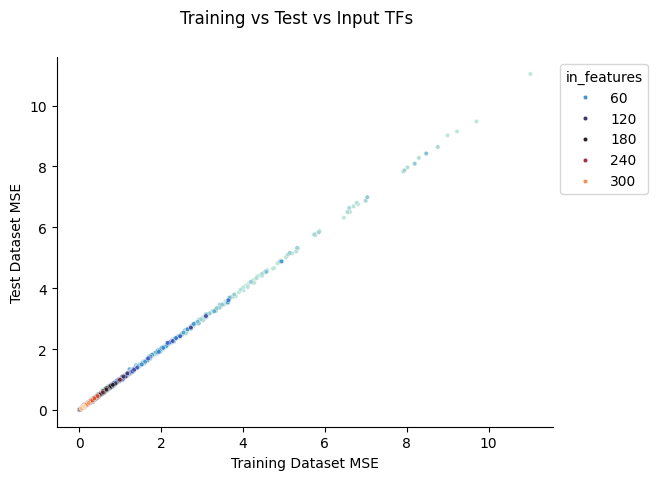

In [ ]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'test_score', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Test Dataset MSE', fontsize = 10)
fig.suptitle('Training vs Test vs Input TFs')
plt.savefig('figures/trainVsTestvsModel', bbox_inches='tight')

In [ ]:
external_res.loc[external_res['external_set_score'] < 1].shape

(13446, 2)

In [ ]:
external_res['log'] = np.log(external_res['external_set_score'] + 1)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_88664/1795373650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])


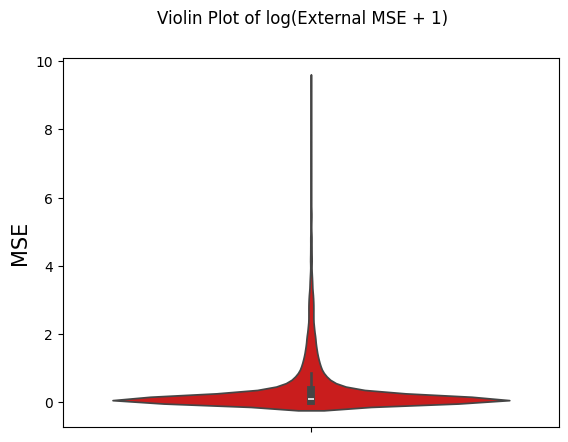

In [ ]:
fig, ax = plt.subplots()
ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])
ax.set_ylabel('MSE', fontsize = 15)
fig.suptitle('Violin Plot of log(External MSE + 1)')
plt.show()
#ax.set_xlabel('Dataset', fontsize = 15)
#fig.canvas.draw()
#labels = [item.get_text() for item in ax.get_xticklabels()]
#labels[0], labels[1] = ['Training', 'Test']
#ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
#fig.suptitle(title, fontsize = 20)
#plt.savefig(figtitle, dpi = 300)

# Correlation and MSE plots

In [1]:
from plotting_functions import create_pearsons_violin

In [10]:
genewise_correlations = pd.read_csv('./data/genewise_correlations', index_col=0)

In [11]:
genewise_correlations['LogMSE'] = np.log(genewise_correlations['MSE']+1)

In [12]:
genewise_correlations

,pearsons,spearmans,MSE,dataset,LogMSE
0,0.150685,0.009660,4.550996,Train,1.713977
1,0.174490,0.124758,0.468027,Train,0.383920
2,0.029496,-0.103851,0.015116,Train,0.015003
3,0.591845,0.667447,0.134081,Train,0.125823
4,0.731884,0.715382,0.130718,Train,0.122853
...,...,...,...,...,...
48236,0.338071,0.280342,0.013308,External,0.013220
48237,0.754317,0.735957,0.119033,External,0.112465
48238,0.656395,0.661307,0.055376,External,0.053897
48239,0.820845,0.807096,0.082152,External,0.078951


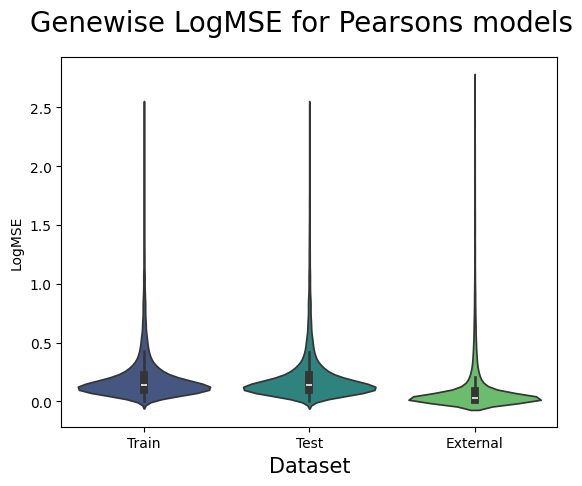

In [13]:
create_pearsons_violin(genewise_correlations, y_col='LogMSE', title = 'Genewise LogMSE for Pearsons models', file_title = 'genewise_LogMSE_PEARSONS')